# 05 — Warranty-Related Review Analysis

## Goal

The purpose of this notebook is to estimate customer satisfaction with the **warranty or guarantee aspect** of each product.

The required workflow is:

1. Load the cleaned NLP datasets.
2. Use pretrained word embeddings to discover terms similar to `warranty` and `guarantee`.
3. Detect common misspellings of the seed terms.
4. Review the candidate terms and create a conservative warranty lexicon.
5. Find reviews that contain at least one accepted warranty-related term.
6. Group the selected reviews by product.
7. Calculate the mean `overall` rating for every product.
8. Validate the detector and save the final tables.

## Dataset-specific decisions

- `reviewText_clean` is used because the text has already been preprocessed.
- `asin` is the product identifier.
- `overall` is the satisfaction score from 1 to 5.
- `brand` and `title` are used only as readable product metadata.
- Train and validation contain `overall`, so both can be used for the final descriptive analysis.
- Test does not contain `overall`, so it can be filtered for warranty mentions but cannot be used to calculate warranty satisfaction.

## Important methodological note

Embedding similarity is used to **generate candidate terms**, not to accept every candidate automatically. Semantically similar words such as `coverage`, `service`, or `replacement` can be ambiguous. The final lexicon therefore uses manual review and conservative context phrases to reduce false positives.

## 1. Install the required libraries

`gensim` provides pretrained word vectors.

`rapidfuzz` provides Levenshtein edit distance for discovering likely spelling mistakes.

In [1]:
!pip -q install -U gensim rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.7 MB/s eta 0:00:00


## 2. Mount Google Drive

In [3]:
from google.colab import drive

# Remount Google Drive so that recently added shortcuts are visible.
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


## 3. Define file paths and load only the required columns

Loading only the columns needed for this task reduces Colab memory usage.

In [4]:
from pathlib import Path

import pandas as pd

# Folder containing the cleaned NLP datasets.
DATA_DIR = Path(
    "/content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp"
)

file_paths = {
    "train": DATA_DIR / "nlp_train_clean.csv",
    "validation": DATA_DIR / "nlp_validation_clean.csv",
    "test": DATA_DIR / "nlp_test_clean.csv",
}

# Validate all input paths before loading the data.
for dataset_name, file_path in file_paths.items():
    if not file_path.exists():
        raise FileNotFoundError(
            f"{dataset_name} file was not found at: {file_path}"
        )

    print(f"{dataset_name}: {file_path}")

train: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/nlp_train_clean.csv
validation: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/nlp_validation_clean.csv
test: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/nlp_test_clean.csv


In [5]:
# These columns are sufficient for warranty detection and product-level analysis.
LABELED_COLUMNS = [
    "row_id",
    "overall",
    "asin",
    "reviewText",
    "reviewText_clean",
    "summary",
    "brand",
    "title",
]

TEST_COLUMNS = [
    "row_id",
    "asin",
    "reviewText",
    "reviewText_clean",
    "summary",
    "brand",
    "title",
]

train = pd.read_csv(
    file_paths["train"],
    usecols=LABELED_COLUMNS,
    low_memory=False,
)

validation = pd.read_csv(
    file_paths["validation"],
    usecols=LABELED_COLUMNS,
    low_memory=False,
)

test = pd.read_csv(
    file_paths["test"],
    usecols=TEST_COLUMNS,
    low_memory=False,
)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

Train shape: (664451, 8)
Validation shape: (166161, 8)
Test shape: (20000, 7)


## 4. Validate the dataset schema

The analysis should stop early if one of the required columns is missing.

In [6]:
REQUIRED_LABELED_COLUMNS = {
    "row_id",
    "overall",
    "asin",
    "reviewText_clean",
    "brand",
    "title",
}

REQUIRED_TEST_COLUMNS = {
    "row_id",
    "asin",
    "reviewText_clean",
    "brand",
    "title",
}

missing_train = REQUIRED_LABELED_COLUMNS - set(train.columns)
missing_validation = REQUIRED_LABELED_COLUMNS - set(validation.columns)
missing_test = REQUIRED_TEST_COLUMNS - set(test.columns)

if missing_train:
    raise ValueError(f"Missing train columns: {sorted(missing_train)}")

if missing_validation:
    raise ValueError(
        f"Missing validation columns: {sorted(missing_validation)}"
    )

if missing_test:
    raise ValueError(f"Missing test columns: {sorted(missing_test)}")

print("All required columns are available.")
print("Test has overall:", "overall" in test.columns)

All required columns are available.
Test has overall: False


## 5. Prepare labeled data

Train and validation are combined for the final descriptive analysis because both contain real `overall` ratings.

The split name is preserved so that results can also be compared across train and validation.

In [7]:
import numpy as np

train = train.copy()
validation = validation.copy()
test = test.copy()

train["split"] = "train"
validation["split"] = "validation"
test["split"] = "test"

# Keep product identifiers as strings.
for dataframe in [train, validation, test]:
    dataframe["asin"] = dataframe["asin"].astype("string")

# Convert ratings safely and keep valid 1-to-5 values.
train["overall"] = pd.to_numeric(train["overall"], errors="coerce")
validation["overall"] = pd.to_numeric(
    validation["overall"],
    errors="coerce",
)

train = train[
    train["overall"].between(1, 5)
    & train["asin"].notna()
].copy()

validation = validation[
    validation["overall"].between(1, 5)
    & validation["asin"].notna()
].copy()

labeled_reviews = pd.concat(
    [train, validation],
    ignore_index=True,
)

print("Labeled review count:", f"{len(labeled_reviews):,}")
print("Unique labeled products:", f"{labeled_reviews['asin'].nunique():,}")

Labeled review count: 830,612
Unique labeled products: 90,715


## 6. Normalize text only for lexical matching

The source text is already cleaned. This step performs only the normalization required for reliable matching:

- lowercase conversion
- HTML entity decoding
- URL removal
- punctuation-to-space conversion
- whitespace normalization

We do **not** remove stopwords, stem words, or lemmatize the text because spelling variants and warranty phrases must remain interpretable.

In [8]:
import html
import re


def normalize_for_matching(text_series):
    """Normalize a pandas text series for term and phrase matching."""

    normalized = text_series.fillna("").astype(str)

    # Decode values such as &amp;.
    normalized = normalized.map(html.unescape)

    # Normalize case.
    normalized = normalized.str.lower()

    # Remove URLs because they do not help warranty detection.
    normalized = normalized.str.replace(
        r"https?://\S+|www\.\S+",
        " ",
        regex=True,
    )

    # Convert hyphens and slashes to spaces.
    normalized = normalized.str.replace(
        r"[-_/]",
        " ",
        regex=True,
    )

    # Keep English letters, digits, apostrophes, and whitespace.
    normalized = normalized.str.replace(
        r"[^a-z0-9'\s]",
        " ",
        regex=True,
    )

    # Collapse repeated whitespace.
    normalized = normalized.str.replace(
        r"\s+",
        " ",
        regex=True,
    ).str.strip()

    return normalized


train["normalized_text"] = normalize_for_matching(
    train["reviewText_clean"]
)

validation["normalized_text"] = normalize_for_matching(
    validation["reviewText_clean"]
)

test["normalized_text"] = normalize_for_matching(
    test["reviewText_clean"]
)

labeled_reviews = pd.concat(
    [train, validation],
    ignore_index=True,
)

display(
    labeled_reviews[
        ["reviewText_clean", "normalized_text"]
    ].head(3)
)

,reviewText_clean,normalized_text
0,I have an older URC-WR7 remote and thought thi...,i have an older urc wr7 remote and thought thi...
1,First time I've EVER had a remote that needed ...,first time i've ever had a remote that needed ...
2,Got them and only 2 of them worked. company ca...,got them and only 2 of them worked company cal...


## 7. Create an exact-keyword baseline

The baseline uses only direct forms of `warranty` and `guarantee`.

This baseline is useful because the expanded approach should find additional reviews through spelling variants and carefully selected related phrases.

In [9]:
BASELINE_PATTERN = re.compile(
    r"\b(?:"
    r"warranty|warranties|"
    r"guarantee|guarantees|guaranteed|guaranteeing"
    r")\b",
    flags=re.IGNORECASE,
)

baseline_mask = labeled_reviews["normalized_text"].str.contains(
    BASELINE_PATTERN,
    na=False,
)

baseline_count = int(baseline_mask.sum())
baseline_rate = 100 * baseline_count / len(labeled_reviews)

print("Exact-keyword matches:", f"{baseline_count:,}")
print("Exact-keyword detection rate:", f"{baseline_rate:.3f}%")

Exact-keyword matches: 17,829
Exact-keyword detection rate: 2.146%


## 8. Load pretrained word embeddings

The GloVe vectors are used to generate semantic candidates around the two seed terms.

The first model download may take a few minutes. A GPU is not required.

In [10]:
import gensim.downloader as gensim_api

EMBEDDING_MODEL_NAME = "glove-wiki-gigaword-100"

embedding_model = gensim_api.load(
    EMBEDDING_MODEL_NAME
)

print("Loaded model:", EMBEDDING_MODEL_NAME)
print("Vector size:", embedding_model.vector_size)

[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded model: glove-wiki-gigaword-100
Vector size: 100


## 9. Generate semantic candidates

For each seed term, retrieve its nearest neighbors using cosine similarity.

The candidates are not yet accepted. They must first be checked for:

- presence in the actual review corpus
- semantic relevance to product warranty
- possible ambiguity

In [11]:
SEED_TERMS = ["warranty", "guarantee"]
SEMANTIC_TOP_N = 60


def generate_semantic_candidates(model, seeds, top_n=60):
    """Return embedding neighbors for all seed terms."""

    rows = []

    for seed in seeds:
        if seed not in model.key_to_index:
            raise KeyError(
                f"The seed term {seed!r} is not available in the model."
            )

        neighbors = model.most_similar(
            seed,
            topn=top_n,
        )

        for candidate, similarity in neighbors:
            candidate = candidate.lower().strip()

            # Keep simple English word candidates.
            if not candidate.isalpha():
                continue

            rows.append(
                {
                    "seed": seed,
                    "candidate": candidate,
                    "cosine_similarity": similarity,
                }
            )

    candidate_table = pd.DataFrame(rows)

    return candidate_table.sort_values(
        ["seed", "cosine_similarity"],
        ascending=[True, False],
    ).reset_index(drop=True)


semantic_candidates = generate_semantic_candidates(
    model=embedding_model,
    seeds=SEED_TERMS,
    top_n=SEMANTIC_TOP_N,
)

display(semantic_candidates.head(30))

,seed,candidate,cosine_similarity
0,guarantee,guarantees,0.893054
1,guarantee,guaranteed,0.865030
2,guarantee,ensure,0.792407
3,guarantee,guaranteeing,0.753973
4,guarantee,assure,0.740063
5,guarantee,necessary,0.722100
6,guarantee,ensuring,0.716447
7,guarantee,insure,0.710767
8,guarantee,secure,0.705532
9,guarantee,adequate,0.705069


## 10. Count semantic candidates in the training corpus

A semantic candidate is useful only if it appears in the real dataset.

Both total occurrence count and document count are calculated:

- `occurrence_count`: total number of appearances
- `document_count`: number of reviews containing the candidate at least once

In [12]:
from collections import Counter
from tqdm.auto import tqdm


def compile_word_pattern(terms):
    """Compile one safe regex for a collection of single-word terms."""

    escaped_terms = [
        re.escape(term)
        for term in sorted(
            set(terms),
            key=len,
            reverse=True,
        )
    ]

    return re.compile(
        r"\b(?:"
        + "|".join(escaped_terms)
        + r")\b"
    )


def count_pattern_matches(text_series, pattern, description):
    """Count total and document-level regex matches in a text series."""

    occurrence_counts = Counter()
    document_counts = Counter()

    for text in tqdm(text_series, desc=description):
        matches = pattern.findall(text)

        if not matches:
            continue

        occurrence_counts.update(matches)
        document_counts.update(set(matches))

    return occurrence_counts, document_counts


semantic_term_list = semantic_candidates[
    "candidate"
].drop_duplicates().tolist()

semantic_pattern = compile_word_pattern(
    semantic_term_list
)

semantic_occurrence_counts, semantic_document_counts = (
    count_pattern_matches(
        text_series=train["normalized_text"],
        pattern=semantic_pattern,
        description="Counting semantic candidates",
    )
)

semantic_candidates["occurrence_count"] = (
    semantic_candidates["candidate"]
    .map(semantic_occurrence_counts)
    .fillna(0)
    .astype(int)
)

semantic_candidates["document_count"] = (
    semantic_candidates["candidate"]
    .map(semantic_document_counts)
    .fillna(0)
    .astype(int)
)

semantic_candidates_in_corpus = semantic_candidates[
    semantic_candidates["document_count"] > 0
].copy()

display(
    semantic_candidates_in_corpus.sort_values(
        ["seed", "cosine_similarity"],
        ascending=[True, False],
    ).head(60)
)

Counting semantic candidates:   0%|          | 0/664451 [00:00<?, ?it/s]

,seed,candidate,cosine_similarity,occurrence_count,document_count
0,guarantee,guarantees,0.893054,113,108
1,guarantee,guaranteed,0.865030,516,505
2,guarantee,ensure,0.792407,2619,2485
3,guarantee,guaranteeing,0.753973,16,16
4,guarantee,assure,0.740063,485,473
5,guarantee,necessary,0.722100,6295,6031
6,guarantee,ensuring,0.716447,256,251
7,guarantee,insure,0.710767,288,279
8,guarantee,secure,0.705532,11129,9915
9,guarantee,adequate,0.705069,4492,4239


## 11. Inspect examples for ambiguous candidates

Embedding neighbors are often semantically broad.

Use this helper before approving terms such as:

- `coverage`
- `protection`
- `service`
- `replacement`
- `assurance`

A term should not be included as a standalone keyword if its examples are frequently unrelated to warranty.

In [13]:
def show_term_examples(term, dataframe=train, n=5):
    """Display random review examples containing one candidate term."""

    term_pattern = re.compile(
        rf"\b{re.escape(term.lower())}\b"
    )

    mask = dataframe["normalized_text"].str.contains(
        term_pattern,
        na=False,
    )

    matches = dataframe.loc[
        mask,
        [
            "row_id",
            "asin",
            "overall",
            "brand",
            "title",
            "reviewText_clean",
        ],
    ]

    print(f"Term: {term}")
    print(f"Matching training reviews: {len(matches):,}")

    if matches.empty:
        return matches

    return matches.sample(
        n=min(n, len(matches)),
        random_state=42,
    )


# Change the term below to inspect other semantic candidates.
display(show_term_examples("coverage", n=5))

Term: coverage
Matching training reviews: 2,854


,row_id,asin,overall,brand,title,reviewText_clean
358390,448020,B00Y01VRSO,5,eero,eero Home WiFi System (Individual) - 1st Gener...,Ive had Eero now for a couple of weeks and I a...
386656,483348,B011HVUEME,5,RTL-SDR Blog,RTL-SDR Blog R820T2 RTL2832U 1PPM TCXO SMA Sof...,With this unit you can turn any dual core PC i...
211144,263965,B00JFOP688,5,D-Link,D-Link Wireless AC1200 Dual Band Wi-Fi Gigabit...,I wanted to extend my WiFi coverage while stil...
387178,484000,B011IFQDTW,2,Luxsure,Luxsure&reg; GT08 Bluetooth Smart Watch Wrist ...,The device is advertised as taking a SIM card ...
131702,164641,B00BSYCZZ0,4,C.Crane,C. Crane CC Pocket AM FM and NOAA Weather Radi...,UPDATED 3/31/16 - I have been contacted by cus...


## 12. Discover likely spelling mistakes with edit distance

The code scans likely `w...` and `g...` tokens from the training corpus and compares them with `warranty` and `guarantee`.

A low Levenshtein distance means that only a small number of insertions, deletions, or substitutions are needed to transform the candidate into the seed word.

The output is still reviewed before final use.

In [14]:
from rapidfuzz.distance import Levenshtein

# Scan only plausible word lengths beginning with w or g.
# This is much more memory-efficient than creating the full corpus vocabulary.
TYPO_SCAN_PATTERN = re.compile(
    r"\b(?:w[a-z]{5,11}|g[a-z]{5,12})\b"
)

typo_scan_counts = Counter()

for text in tqdm(
    train["normalized_text"],
    desc="Scanning possible typo tokens",
):
    typo_scan_counts.update(
        TYPO_SCAN_PATTERN.findall(text)
    )

print(
    "Unique candidate tokens scanned:",
    f"{len(typo_scan_counts):,}",
)

Scanning possible typo tokens:   0%|          | 0/664451 [00:00<?, ?it/s]

Unique candidate tokens scanned: 5,880


In [15]:
KNOWN_NON_TYPO_FORMS = {
    "warranty",
    "warranties",
    "warrant",
    "warrants",
    "warranted",
    "warranting",
    "guarantee",
    "guarantees",
    "guaranteed",
    "guaranteeing",
    "guaranty",
    "guaranties",
    "guarantor",
    "guarantors",
}


def build_typo_candidate_table(
    token_counts,
    seeds,
    max_distance=2,
    min_frequency=2,
):
    """Find corpus tokens with small edit distance from the seed terms."""

    rows = []

    for token, frequency in token_counts.items():
        if frequency < min_frequency:
            continue

        best_seed = None
        best_distance = None
        best_similarity = None

        for seed in seeds:
            distance = Levenshtein.distance(
                token,
                seed,
                score_cutoff=max_distance,
            )

            if distance > max_distance:
                continue

            similarity = Levenshtein.normalized_similarity(
                token,
                seed,
            )

            if (
                best_distance is None
                or distance < best_distance
                or (
                    distance == best_distance
                    and similarity > best_similarity
                )
            ):
                best_seed = seed
                best_distance = distance
                best_similarity = similarity

        if best_seed is None:
            continue

        rows.append(
            {
                "candidate": token,
                "closest_seed": best_seed,
                "edit_distance": best_distance,
                "normalized_similarity": best_similarity,
                "frequency": frequency,
                "known_valid_form": (
                    token in KNOWN_NON_TYPO_FORMS
                ),
            }
        )

    typo_table = pd.DataFrame(rows)

    if typo_table.empty:
        return typo_table

    return typo_table.sort_values(
        [
            "known_valid_form",
            "edit_distance",
            "frequency",
        ],
        ascending=[True, True, False],
    ).reset_index(drop=True)


typo_candidates = build_typo_candidate_table(
    token_counts=typo_scan_counts,
    seeds=SEED_TERMS,
    max_distance=2,
    min_frequency=2,
)

display(typo_candidates.head(100))

,candidate,closest_seed,edit_distance,normalized_similarity,frequency,known_valid_form
0,warrenty,warranty,1,0.875000,89,False
1,waranty,warranty,1,0.875000,20,False
2,guarentee,guarantee,1,0.888889,11,False
3,warrany,warranty,1,0.875000,7,False
4,warrantly,warranty,1,0.888889,5,False
5,gurantee,guarantee,1,0.888889,4,False
6,watranty,warranty,1,0.875000,3,False
7,warrantee,warranty,2,0.777778,184,False
8,warantee,guarantee,2,0.777778,11,False
9,gaurantee,guarantee,2,0.777778,6,False


## 13. Build the final warranty lexicon

### Why the lexicon is conservative

Words such as `coverage`, `service`, `support`, `return`, and `replacement` are not accepted alone because they frequently refer to non-warranty topics.

Instead, ambiguous concepts are included only inside precise phrases such as:

- `protection plan`
- `extended service plan`
- `service contract`
- `warranty coverage`

The automatically discovered typo terms are included only when they are close to a seed and are not known ordinary words.

In [16]:
# Direct forms that explicitly mention warranty or guarantee.
CORE_TERMS = {
    "warranty",
    "warranties",
    "warrantied",
    "guarantee",
    "guarantees",
    "guaranteed",
    "guaranteeing",
    "guaranty",
    "guaranties",
}

# Candidate embedding terms are accepted only through an explicit allowlist.
# Broad terms such as coverage and protection are handled through phrases.
SEMANTIC_ALLOWLIST = {
    "warranties",
    "guaranty",
    "guaranties",
    "guarantees",
    "guaranteed",
    "guaranteeing",
}

APPROVED_SEMANTIC_TERMS = set(
    semantic_candidates_in_corpus.loc[
        semantic_candidates_in_corpus[
            "candidate"
        ].isin(SEMANTIC_ALLOWLIST),
        "candidate",
    ]
)

# Common misspellings are included as a safety net.
# Terms not present in the corpus do not create matches.
COMMON_MANUAL_TYPOS = {
    "waranty",
    "warrenty",
    "warantee",
    "warrantee",
    "warrany",
    "warraty",
    "guarentee",
    "guarante",
    "gurantee",
    "garantee",
    "gaurantee",
    "guarrantee",
    "guarenty",
}

# Automatically accept close tokens, except known valid but ambiguous words.
AUTO_TYPO_TERMS = set()

if not typo_candidates.empty:
    AUTO_TYPO_TERMS = set(
        typo_candidates.loc[
            (~typo_candidates["known_valid_form"])
            & (typo_candidates["edit_distance"] <= 2)
            & (typo_candidates["frequency"] >= 2),
            "candidate",
        ]
    )

TYPO_TERMS = (
    COMMON_MANUAL_TYPOS
    | AUTO_TYPO_TERMS
)

# Precise multi-word expressions that describe warranty-like concepts.
PHRASE_TERMS = {
    "extended warranty",
    "limited warranty",
    "lifetime warranty",
    "manufacturer warranty",
    "manufacturers warranty",
    "manufacturer's warranty",
    "factory warranty",
    "warranty coverage",
    "warranty claim",
    "warranty period",
    "warranty service",
    "warranty repair",
    "warranty replacement",
    "warranty support",
    "under warranty",
    "out of warranty",
    "void warranty",
    "voided warranty",
    "extended guarantee",
    "limited guarantee",
    "lifetime guarantee",
    "money back guarantee",
    "money back guaranteed",
    "satisfaction guarantee",
    "guarantee period",
    "protection plan",
    "product protection plan",
    "extended protection plan",
    "extended service plan",
    "service contract",
    "accidental damage protection",
}

FINAL_TERMS = (
    CORE_TERMS
    | APPROVED_SEMANTIC_TERMS
    | TYPO_TERMS
    | PHRASE_TERMS
)

print("Core terms:", len(CORE_TERMS))
print("Approved semantic terms:", len(APPROVED_SEMANTIC_TERMS))
print("Typo terms:", len(TYPO_TERMS))
print("Phrase terms:", len(PHRASE_TERMS))
print("Final lexicon size:", len(FINAL_TERMS))

Core terms: 9
Approved semantic terms: 4
Typo terms: 21
Phrase terms: 31
Final lexicon size: 61


## 14. Create a term-source table

This table documents why each term is present in the final lexicon.

In [17]:
term_sources = {}

for term in CORE_TERMS:
    term_sources.setdefault(term, set()).add("core")

for term in APPROVED_SEMANTIC_TERMS:
    term_sources.setdefault(term, set()).add("embedding")

for term in TYPO_TERMS:
    term_sources.setdefault(term, set()).add("typo")

for term in PHRASE_TERMS:
    term_sources.setdefault(term, set()).add("phrase")


lexicon_table = pd.DataFrame(
    [
        {
            "term": term,
            "source": " | ".join(
                sorted(term_sources[term])
            ),
        }
        for term in sorted(term_sources)
    ]
)

display(lexicon_table)

,term,source
0,accidental damage protection,phrase
1,extended guarantee,phrase
2,extended protection plan,phrase
3,extended service plan,phrase
4,extended warranty,phrase
...,...,...
56,warraty,typo
57,warrent,typo
58,warrenty,typo
59,watranty,typo


## 15. Compile the final matcher

Longer phrases are matched before shorter words.

Word boundaries prevent partial matches inside unrelated longer tokens.

In [18]:
def term_to_regex(term):
    """Convert a word or phrase to a safe regex fragment."""

    words = term.split()

    return r"\s+".join(
        re.escape(word)
        for word in words
    )


ordered_final_terms = sorted(
    FINAL_TERMS,
    key=lambda term: (
        len(term.split()),
        len(term),
    ),
    reverse=True,
)

WARRANTY_PATTERN = re.compile(
    r"\b(?:"
    + "|".join(
        term_to_regex(term)
        for term in ordered_final_terms
    )
    + r")\b",
    flags=re.IGNORECASE,
)


def extract_unique_matches(text):
    """Extract unique warranty-related matches from one review."""

    matches = {
        match.group(0).lower()
        for match in WARRANTY_PATTERN.finditer(text)
    }

    return sorted(matches)


print("Final regex compiled successfully.")

Final regex compiled successfully.


## 16. Detect warranty-related labeled reviews

The expensive match extraction is performed only for rows that first pass the boolean regex filter.

In [19]:
expanded_mask = labeled_reviews[
    "normalized_text"
].str.contains(
    WARRANTY_PATTERN,
    na=False,
)

warranty_reviews = labeled_reviews.loc[
    expanded_mask
].copy()

warranty_reviews["matched_terms"] = (
    warranty_reviews["normalized_text"]
    .map(extract_unique_matches)
)

warranty_reviews["matched_terms_text"] = (
    warranty_reviews["matched_terms"]
    .map(lambda terms: " | ".join(terms))
)

expanded_count = len(warranty_reviews)
expanded_rate = 100 * expanded_count / len(labeled_reviews)

print("All labeled reviews:", f"{len(labeled_reviews):,}")
print("Warranty-related reviews:", f"{expanded_count:,}")
print("Expanded detection rate:", f"{expanded_rate:.3f}%")

All labeled reviews: 830,612
Warranty-related reviews: 18,494
Expanded detection rate: 2.227%


## 17. Compare the baseline and expanded detector

An increase is expected because the expanded detector includes:

- spelling mistakes
- morphological variants
- precise warranty-related phrases

A very large increase should be investigated because it can indicate overly broad terms.

In [20]:
detection_comparison = pd.DataFrame(
    {
        "method": [
            "Exact keyword baseline",
            "Expanded reviewed lexicon",
        ],
        "matched_reviews": [
            baseline_count,
            expanded_count,
        ],
        "percentage_of_labeled_reviews": [
            baseline_rate,
            expanded_rate,
        ],
    }
)

detection_comparison[
    "additional_reviews_vs_baseline"
] = (
    detection_comparison["matched_reviews"]
    - baseline_count
)

display(detection_comparison.round(4))

,method,matched_reviews,percentage_of_labeled_reviews,additional_reviews_vs_baseline
0,Exact keyword baseline,17829,2.1465,0
1,Expanded reviewed lexicon,18494,2.2266,665


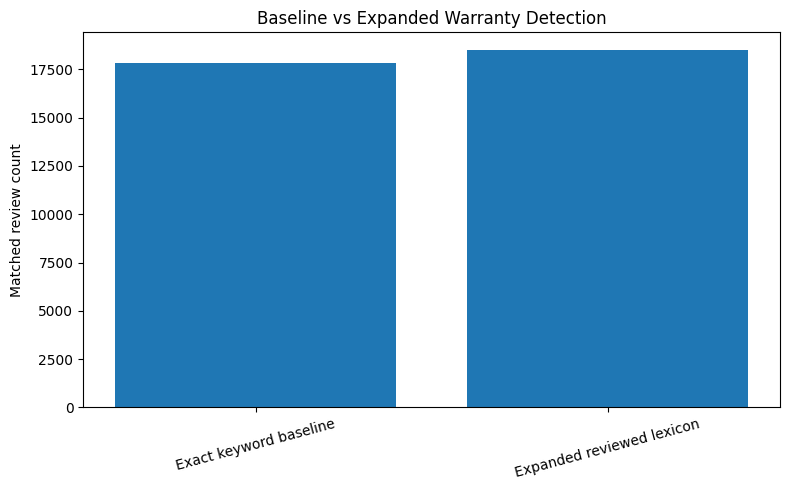

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    detection_comparison["method"],
    detection_comparison["matched_reviews"],
)
plt.ylabel("Matched review count")
plt.title("Baseline vs Expanded Warranty Detection")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 18. Inspect which terms produced the matches

This table is one of the most important quality checks.

A suspicious broad term with a very large count should be inspected and possibly removed.

In [22]:
matched_term_counts = Counter()

for terms in warranty_reviews["matched_terms"]:
    matched_term_counts.update(terms)

matched_term_table = pd.DataFrame(
    matched_term_counts.most_common(),
    columns=[
        "matched_term",
        "review_count",
    ],
)

matched_term_table["percentage_of_warranty_reviews"] = (
    100
    * matched_term_table["review_count"]
    / len(warranty_reviews)
)

display(
    matched_term_table.head(50).round(3)
)

,matched_term,review_count,percentage_of_warranty_reviews
0,warranty,11499,62.177
1,guarantee,1380,7.462
2,under warranty,1357,7.338
3,lifetime warranty,954,5.158
4,out of warranty,862,4.661
5,guaranteed,610,3.298
6,extended warranty,568,3.071
7,warranty period,521,2.817
8,warranties,413,2.233
9,protection plan,343,1.855


## 19. Create context snippets for manual auditing

Keyword detection is not sufficient by itself. A random audit should check whether the matched review is genuinely discussing product warranty or guarantee.

The context window shows the text around the first match.

In [23]:
def create_match_context(text, window=180):
    """Return text around the first warranty-related match."""

    match = WARRANTY_PATTERN.search(text)

    if match is None:
        return ""

    start = max(0, match.start() - window)
    end = min(len(text), match.end() + window)

    snippet = text[start:end]

    if start > 0:
        snippet = "..." + snippet

    if end < len(text):
        snippet = snippet + "..."

    return snippet


warranty_reviews["match_context"] = (
    warranty_reviews["normalized_text"]
    .map(create_match_context)
)

AUDIT_SAMPLE_SIZE = min(
    60,
    len(warranty_reviews),
)

audit_sample = warranty_reviews.sample(
    n=AUDIT_SAMPLE_SIZE,
    random_state=42,
)[
    [
        "split",
        "row_id",
        "asin",
        "overall",
        "brand",
        "title",
        "matched_terms_text",
        "match_context",
    ]
]

display(audit_sample.head(30))

,split,row_id,asin,overall,brand,title,matched_terms_text,match_context
169777,train,212248,B00FE690DI,5,Asus,ASUS MB168B 15.6&quot; WXGA 1366x768 USB Porta...,warranty,...rom plugging unplugging and also suspect th...
335928,train,419933,B00VIRG3GO,5,Yamaha Audio,Yamaha RX-V679BL 7.2-Channel MusicCast AV Rec...,protection plan,...risp music is awesome in 2ch movies are the...
41067,train,51336,B00261HV2Q,3,ARCTIC,ARCTIC F12 Pro PWM PST - 120 mm PWM PST Case F...,warranty,... spend the money on some reputable fans and...
206271,train,257881,B00IZYEEUA,5,Coastacloud,Coastacloud iPad 2/3/4 Magnetic Smart Cover fo...,guarantee,...ount in exchange for an honest and unbiased...
128729,train,160924,B00BIY0DFY,1,Uniden,Uniden UDR444 Guardian 4.3-Inch Video Surveill...,warranty,bought in october now january so of course the...
356568,train,445737,B00XS423SC,2,Seagate,Seagate Archive HDD 8TB SATA 6GBps 128MB Cache...,warranties | warranty,warning these hard drives do not have warranti...
183452,train,229340,B00H33SFJU,1,EVGA,"EVGA 500 W1, 80+ WHITE 500W, 3 Year Warranty, ...",warranty service,it worked fine for a year then the fan failed ...
148652,train,185839,B00DI88X32,5,KabelDirekt,KabelDirekt Pro Series 10 feet 3.5mm Audio Au...,warranty,just broke after 8 months light usage lying on...
669923,validation,27409,B000P0R6LQ,1,Polk Audio,Polk Audio DB6501 6.5-Inch 2-Way Component Sys...,warranty | warranty period,...ard a pop figured out it was cross over fai...
803566,validation,695451,B01FDPW1NK,2,Samsung,"Samsung Gear Fit2- Pink, Medium/Large",warranty,...r 30 days it was lost while hiking because ...


## 20. Compare train and validation detection

Similar rates and rating behavior across the two splits provide a basic stability check.

In [24]:
split_summary = (
    warranty_reviews
    .groupby("split")
    .agg(
        warranty_review_count=("row_id", "size"),
        unique_products=("asin", "nunique"),
        mean_warranty_rating=("overall", "mean"),
        median_warranty_rating=("overall", "median"),
    )
    .reset_index()
)

split_sizes = (
    labeled_reviews
    .groupby("split")
    .size()
    .rename("all_review_count")
    .reset_index()
)

split_summary = split_summary.merge(
    split_sizes,
    on="split",
    how="left",
)

split_summary["detection_rate_percent"] = (
    100
    * split_summary["warranty_review_count"]
    / split_summary["all_review_count"]
)

display(split_summary.round(4))

,split,warranty_review_count,unique_products,mean_warranty_rating,median_warranty_rating,all_review_count,detection_rate_percent
0,train,14851,8633,3.2100,4.0,664451,2.2351
1,validation,3643,2930,3.1806,3.0,166161,2.1925


## 21. Analyze the rating distribution of warranty-related reviews

In [25]:
warranty_rating_distribution = (
    warranty_reviews["overall"]
    .value_counts()
    .sort_index()
    .rename_axis("overall")
    .reset_index(name="review_count")
)

warranty_rating_distribution["percentage"] = (
    100
    * warranty_rating_distribution["review_count"]
    / warranty_rating_distribution[
        "review_count"
    ].sum()
)

display(warranty_rating_distribution.round(3))

,overall,review_count,percentage
0,1,5216,28.204
1,2,2051,11.090
2,3,1864,10.079
3,4,2467,13.339
4,5,6896,37.288


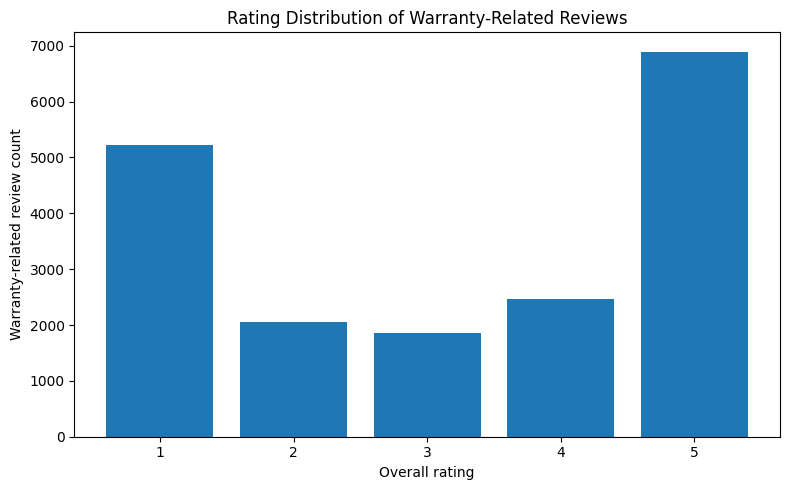

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(
    warranty_rating_distribution["overall"],
    warranty_rating_distribution["review_count"],
)
plt.xlabel("Overall rating")
plt.ylabel("Warranty-related review count")
plt.title("Rating Distribution of Warranty-Related Reviews")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

## 22. Create stable product metadata

Products are grouped only by `asin`.

Grouping by `asin`, `brand`, and `title` together could accidentally split one product when metadata contains small formatting differences. The most frequent non-empty brand and title are therefore selected separately.

In [27]:
def most_frequent_non_empty(series):
    """Return the most frequent non-empty string in a series."""

    cleaned = (
        series.dropna()
        .astype(str)
        .map(html.unescape)
        .str.strip()
    )

    cleaned = cleaned[cleaned.ne("")]

    if cleaned.empty:
        return np.nan

    modes = cleaned.mode()

    if not modes.empty:
        return modes.iloc[0]

    return cleaned.iloc[0]


product_metadata = (
    labeled_reviews
    .groupby("asin", as_index=False)
    .agg(
        brand=("brand", most_frequent_non_empty),
        title=("title", most_frequent_non_empty),
    )
)

display(product_metadata.head())

,asin,brand,title
0,0101635370,Crazy Cart,abcGoodefg® 4GB USB 2.0 Mp3 Music Player with ...
1,0380709473,Erle Stanley Gardner,Crows Can't Count
2,0511189877,URC,CLIKR-5 Time Warner Cable Remote Control UR5U-...
3,0528881469,Rand McNally,Rand McNally 528881469 7-inch Intelliroute TND...
4,0545105668,Visit Amazon's Roland Smith Page,Elephant Run


## 23. Calculate the required product-level warranty satisfaction

The required measure is:

> Mean `overall` rating among warranty-related reviews for each product.

The output also includes review count, median, standard deviation, and positive/negative shares so the mean can be interpreted responsibly.

In [28]:
product_warranty_stats = (
    warranty_reviews
    .groupby("asin", as_index=False)
    .agg(
        warranty_review_count=("overall", "size"),
        warranty_rating_sum=("overall", "sum"),
        warranty_average_rating=("overall", "mean"),
        warranty_median_rating=("overall", "median"),
        warranty_rating_std=("overall", "std"),
        positive_rating_share=(
            "overall",
            lambda ratings: (ratings >= 4).mean(),
        ),
        neutral_rating_share=(
            "overall",
            lambda ratings: (ratings == 3).mean(),
        ),
        negative_rating_share=(
            "overall",
            lambda ratings: (ratings <= 2).mean(),
        ),
    )
)

product_satisfaction = product_warranty_stats.merge(
    product_metadata,
    on="asin",
    how="left",
)

product_satisfaction[
    "warranty_rating_std"
] = product_satisfaction[
    "warranty_rating_std"
].fillna(0)

numeric_columns = [
    "warranty_average_rating",
    "warranty_median_rating",
    "warranty_rating_std",
    "positive_rating_share",
    "neutral_rating_share",
    "negative_rating_share",
]

product_satisfaction[
    numeric_columns
] = product_satisfaction[
    numeric_columns
].round(4)

product_satisfaction = product_satisfaction[
    [
        "asin",
        "brand",
        "title",
        "warranty_review_count",
        "warranty_average_rating",
        "warranty_median_rating",
        "warranty_rating_std",
        "positive_rating_share",
        "neutral_rating_share",
        "negative_rating_share",
        "warranty_rating_sum",
    ]
].sort_values(
    [
        "warranty_review_count",
        "warranty_average_rating",
    ],
    ascending=[False, False],
).reset_index(drop=True)

display(product_satisfaction.head(20))

,asin,brand,title,warranty_review_count,warranty_average_rating,warranty_median_rating,warranty_rating_std,positive_rating_share,neutral_rating_share,negative_rating_share,warranty_rating_sum
0,B0163CHND0,Microsoft,Microsoft Band 2 - Medium,50,1.6800,1.0,1.0388,0.0600,0.1200,0.8200,84
1,B00LF10KTE,Samsung,Samsung 850 PRO - 1TB - 2.5-Inch SATA III Inte...,47,4.0426,5.0,1.5174,0.7234,0.0851,0.1915,190
2,B00IVPU7AO,Samsung,Samsung EVO 64GB 48/MB/s Micro SDXC Memory Ca...,46,1.7174,1.0,1.2049,0.1087,0.0870,0.8043,79
3,B00DSUTX3O,Western Digital,WD Black 750GB Performance Mobile Hard Disk Dr...,42,4.1905,5.0,1.3478,0.8095,0.0238,0.1667,176
4,B008VQ8IKY,Western Digital,WD Red 8TB NAS Hard Disk Drive - 5400 RPM Clas...,40,3.3500,4.0,1.7328,0.5250,0.1250,0.3500,134
5,B004LB5AZY,Corsair,"CORSAIR CSM Series, CS550M, 550 Watt, 80+ Gold...",35,4.4857,5.0,1.1725,0.8857,0.0286,0.0857,157
6,B00S9SGNNS,Asus,ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up...,32,2.9062,3.0,1.7107,0.4062,0.1250,0.4688,93
7,B000HPV3RW,Belkin,Belkin 8-Outlet Power Strip Surge Protector wi...,31,3.8710,5.0,1.4998,0.7097,0.0968,0.1935,120
8,B00N1O1NQW,Syncwire,iPhone Charger Syncwire Lightning Cable - [App...,29,5.0000,5.0,0.0000,1.0000,0.0000,0.0000,145
9,B013HSW4N2,Jaybird,Jaybird X2 Wireless Sweat-Proof Micro-Sized Bl...,29,2.8621,3.0,1.7264,0.4483,0.0690,0.4828,83


## 24. Add a reliability label

The project requires the raw mean, but an average based on one review is unstable.

The count-based label does not replace the required mean. It only helps interpretation.

In [29]:
def assign_evidence_level(review_count):
    """Assign a simple evidence label based on review count."""

    if review_count == 1:
        return "very low"

    if review_count <= 4:
        return "low"

    if review_count <= 9:
        return "moderate"

    return "stronger"


product_satisfaction["evidence_level"] = (
    product_satisfaction[
        "warranty_review_count"
    ].map(assign_evidence_level)
)

display(
    product_satisfaction[
        [
            "asin",
            "brand",
            "title",
            "warranty_review_count",
            "warranty_average_rating",
            "evidence_level",
        ]
    ].head(20)
)

,asin,brand,title,warranty_review_count,warranty_average_rating,evidence_level
0,B0163CHND0,Microsoft,Microsoft Band 2 - Medium,50,1.6800,stronger
1,B00LF10KTE,Samsung,Samsung 850 PRO - 1TB - 2.5-Inch SATA III Inte...,47,4.0426,stronger
2,B00IVPU7AO,Samsung,Samsung EVO 64GB 48/MB/s Micro SDXC Memory Ca...,46,1.7174,stronger
3,B00DSUTX3O,Western Digital,WD Black 750GB Performance Mobile Hard Disk Dr...,42,4.1905,stronger
4,B008VQ8IKY,Western Digital,WD Red 8TB NAS Hard Disk Drive - 5400 RPM Clas...,40,3.3500,stronger
5,B004LB5AZY,Corsair,"CORSAIR CSM Series, CS550M, 550 Watt, 80+ Gold...",35,4.4857,stronger
6,B00S9SGNNS,Asus,ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up...,32,2.9062,stronger
7,B000HPV3RW,Belkin,Belkin 8-Outlet Power Strip Surge Protector wi...,31,3.8710,stronger
8,B00N1O1NQW,Syncwire,iPhone Charger Syncwire Lightning Cable - [App...,29,5.0000,stronger
9,B013HSW4N2,Jaybird,Jaybird X2 Wireless Sweat-Proof Micro-Sized Bl...,29,2.8621,stronger


## 25. Rank products with a minimum evidence threshold

Products with only one warranty-related review should remain in the full output, but they should not dominate highest/lowest satisfaction rankings.

The threshold can be changed after inspecting the count distribution.

In [30]:
MIN_REVIEWS_FOR_RANKING = 3

reliable_products = product_satisfaction[
    product_satisfaction[
        "warranty_review_count"
    ] >= MIN_REVIEWS_FOR_RANKING
].copy()

highest_satisfaction = (
    reliable_products
    .sort_values(
        [
            "warranty_average_rating",
            "warranty_review_count",
        ],
        ascending=[False, False],
    )
    .head(20)
)

lowest_satisfaction = (
    reliable_products
    .sort_values(
        [
            "warranty_average_rating",
            "warranty_review_count",
        ],
        ascending=[True, False],
    )
    .head(20)
)

print(
    "Products with at least one warranty review:",
    f"{len(product_satisfaction):,}",
)

print(
    f"Products with at least "
    f"{MIN_REVIEWS_FOR_RANKING} warranty reviews:",
    f"{len(reliable_products):,}",
)

print("\nHighest warranty satisfaction:")
display(
    highest_satisfaction[
        [
            "asin",
            "brand",
            "title",
            "warranty_review_count",
            "warranty_average_rating",
            "positive_rating_share",
        ]
    ]
)

print("\nLowest warranty satisfaction:")
display(
    lowest_satisfaction[
        [
            "asin",
            "brand",
            "title",
            "warranty_review_count",
            "warranty_average_rating",
            "negative_rating_share",
        ]
    ]
)

Products with at least one warranty review: 10,104
Products with at least 3 warranty reviews: 1,518

Highest warranty satisfaction:


,asin,brand,title,warranty_review_count,warranty_average_rating,positive_rating_share
8,B00N1O1NQW,Syncwire,iPhone Charger Syncwire Lightning Cable - [App...,29,5.0,1.0
169,B00EKJQM5E,EVGA,"EVGA SuperNOVA 1000 P2, 80+ PLATINUM 1000W, Fu...",9,5.0,1.0
246,B00650P2ZC,Noctua,"Noctua NF-F12 PWM, 4-Pin Premium Quiet Fan (12...",7,5.0,1.0
247,B015PC7R6W,Syncwire,Syncwire Lightning to USB A Cable - Nylon Brai...,7,5.0,1.0
323,B0002SKHIK,Pelican,Pelican 1510 Case With Foam (Black),6,5.0,1.0
324,B00PK00WRG,Breakthrough Photography,82mm X2 UV Filter For Camera Lenses - UV Prote...,6,5.0,1.0
435,B00EU799O2,Snugg,"Macbook Pro 15 Sleeve, Snugg - Brown Leather S...",5,5.0,1.0
436,B00O0KISQE,Anker,Anker USB 3.0 4-Port Portable Aluminum Hub wit...,5,5.0,1.0
437,B00RNGOBYK,amFilm,amFilm iPad 9.7 Screen Protector Tempered Glas...,5,5.0,1.0
438,B00SJHK1GE,Blitzby,Blitzby Apple Watch Screen Protector 44mm (7 P...,5,5.0,1.0



Lowest warranty satisfaction:


,asin,brand,title,warranty_review_count,warranty_average_rating,negative_rating_share
433,B008FC8FJ8,ViewSonic,ViewSonic VFD820-50 8-Inch Digital Photo Frame...,6,1.0,1.0
434,B0111MRL4S,NETGEAR,NETGEAR Nighthawk AC1900 VDSL/ADSL Modem Route...,6,1.0,1.0
594,B00O8B7CP8,Pioneer,Pioneer AVH-X3700BHS DVD Receiver with 6.2-Inc...,5,1.0,1.0
595,B00WWI9UW2,ViewSonic,ViewSonic VFD820-70 8-Inch Digital Photo Frame...,5,1.0,1.0
596,B01606KJ6C,Microsoft,"Microsoft Surface Pro 4 (128 GB, 4 GB RAM, Int...",5,1.0,1.0
868,B00I8O6OQ4,Seagate,(Old Model) Seagate 2TB Laptop HDD SATA III 2....,4,1.0,1.0
869,B00J65WQHU,NETGEAR,Netgear C6300-100NAS AC1750 (16x4) DOCSIS 3.0 ...,4,1.0,1.0
870,B00NPZG6DW,Parrot,Parrot Zik 2.0 Wireless Noise Cancelling Headp...,4,1.0,1.0
871,B00TYFCJ8S,Sony,Sony BDPS3500 Blu-ray Player with Wi-Fi (2015 ...,4,1.0,1.0
872,B019PZDJEE,VIZIO,VIZIO 32-Inch 1080 p Smart LED TV D32-D1 (2016),4,1.0,1.0


## 26. Show products with the largest amount of warranty evidence

A high review count gives a more stable view of warranty satisfaction than a single review.

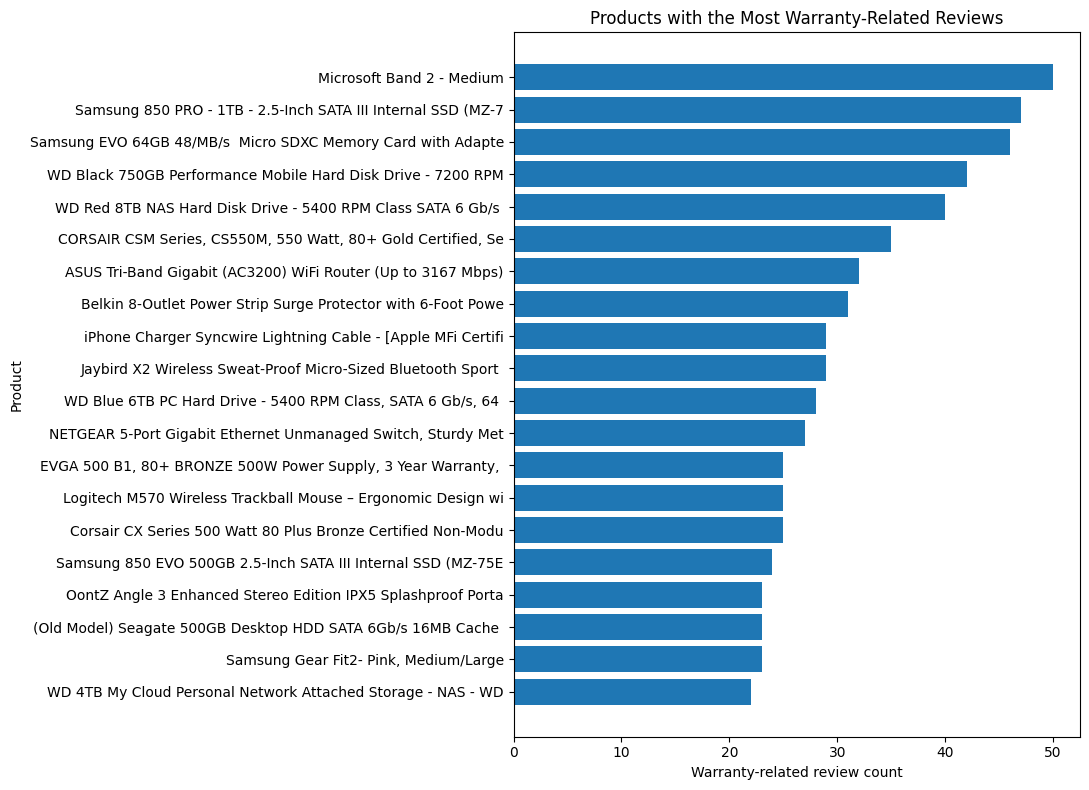

In [31]:
top_products_by_volume = (
    product_satisfaction
    .head(20)
    .copy()
)

plot_labels = (
    top_products_by_volume["title"]
    .fillna(top_products_by_volume["asin"])
    .astype(str)
    .str.slice(0, 60)
)

plt.figure(figsize=(11, 8))
plt.barh(
    plot_labels[::-1],
    top_products_by_volume[
        "warranty_review_count"
    ][::-1],
)
plt.xlabel("Warranty-related review count")
plt.ylabel("Product")
plt.title("Products with the Most Warranty-Related Reviews")
plt.tight_layout()
plt.show()

## 27. Optional bonus: calculate a smoothed rating

The raw mean is the required answer.

The smoothed score is an optional ranking aid that moves very small-sample product means toward the global warranty mean.

This prevents a product with one five-star review from automatically looking better than a product with many consistently positive warranty reviews.

In [32]:
GLOBAL_WARRANTY_MEAN = (
    warranty_reviews["overall"].mean()
)

PRIOR_STRENGTH = 5

product_satisfaction[
    "smoothed_warranty_rating"
] = (
    product_satisfaction[
        "warranty_rating_sum"
    ]
    + PRIOR_STRENGTH
    * GLOBAL_WARRANTY_MEAN
) / (
    product_satisfaction[
        "warranty_review_count"
    ]
    + PRIOR_STRENGTH
)

product_satisfaction[
    "smoothed_warranty_rating"
] = product_satisfaction[
    "smoothed_warranty_rating"
].round(4)

print(
    "Global warranty-related mean rating:",
    round(GLOBAL_WARRANTY_MEAN, 4),
)

display(
    product_satisfaction[
        [
            "asin",
            "brand",
            "title",
            "warranty_review_count",
            "warranty_average_rating",
            "smoothed_warranty_rating",
        ]
    ].head(20)
)

Global warranty-related mean rating: 3.2042


,asin,brand,title,warranty_review_count,warranty_average_rating,smoothed_warranty_rating
0,B0163CHND0,Microsoft,Microsoft Band 2 - Medium,50,1.6800,1.8186
1,B00LF10KTE,Samsung,Samsung 850 PRO - 1TB - 2.5-Inch SATA III Inte...,47,4.0426,3.9619
2,B00IVPU7AO,Samsung,Samsung EVO 64GB 48/MB/s Micro SDXC Memory Ca...,46,1.7174,1.8632
3,B00DSUTX3O,Western Digital,WD Black 750GB Performance Mobile Hard Disk Dr...,42,4.1905,4.0856
4,B008VQ8IKY,Western Digital,WD Red 8TB NAS Hard Disk Drive - 5400 RPM Clas...,40,3.3500,3.3338
5,B004LB5AZY,Corsair,"CORSAIR CSM Series, CS550M, 550 Watt, 80+ Gold...",35,4.4857,4.3255
6,B00S9SGNNS,Asus,ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up...,32,2.9062,2.9465
7,B000HPV3RW,Belkin,Belkin 8-Outlet Power Strip Surge Protector wi...,31,3.8710,3.7784
8,B00N1O1NQW,Syncwire,iPhone Charger Syncwire Lightning Cable - [App...,29,5.0000,4.7359
9,B013HSW4N2,Jaybird,Jaybird X2 Wireless Sweat-Proof Micro-Sized Bl...,29,2.8621,2.9124


## 28. Apply the detector to the test set

The test dataset has no `overall` label.

Therefore:

- warranty-related test reviews can be identified and exported
- warranty satisfaction cannot be calculated from test alone

In [33]:
test_mask = test["normalized_text"].str.contains(
    WARRANTY_PATTERN,
    na=False,
)

warranty_test_reviews = test.loc[
    test_mask
].copy()

warranty_test_reviews["matched_terms"] = (
    warranty_test_reviews[
        "normalized_text"
    ].map(extract_unique_matches)
)

warranty_test_reviews[
    "matched_terms_text"
] = warranty_test_reviews[
    "matched_terms"
].map(
    lambda terms: " | ".join(terms)
)

print("All test reviews:", f"{len(test):,}")
print(
    "Warranty-related test reviews:",
    f"{len(warranty_test_reviews):,}",
)
print(
    "Test detection rate:",
    f"{100 * len(warranty_test_reviews) / len(test):.3f}%",
)

display(
    warranty_test_reviews[
        [
            "row_id",
            "asin",
            "brand",
            "title",
            "matched_terms_text",
            "reviewText_clean",
        ]
    ].head(10)
)

All test reviews: 20,000
Warranty-related test reviews: 638
Test detection rate: 3.190%


,row_id,asin,brand,title,matched_terms_text,reviewText_clean
3,3,B00FBJ4KYC,SquareTrade,SquareTrade 4-Year Home Security Protection Pl...,protection plan | warranty,I purchased this 4 year protection plan for a ...
47,47,B01BGTG41W,SanDisk,SanDisk Ultra Fit 32GB USB 3.0 Flash Drive - S...,under warranty,My drive came with FAT32 format and I did not ...
67,67,B00SMBFZ0Y,VIZIO,VIZIO SS2521-C6 25-Inch 2.1 Channel Sound Stan...,limited warranty,Base is too much as other reviews said. Even w...
88,88,B01FN69EDE,The Liteway 305,[Black] Best Seller Wireless Stereo Bluetooth ...,warranty,Worked for about a month then it would not cha...
128,128,B01EKDXM3O,LG,LG Electronics MAIN-69555 LG Tone Pro HBS-770 ...,under warranty | warranty,Mine stopped working after only a few months w...
131,131,B00NQNI3FW,Fintie,Fintie Case for Kindle Voyage - [The Thinnest ...,warranty claim,The case cracked and a chunk of plastic fell o...
140,140,B01F5EE0DS,zhi yun,Zhiyun Smooth-II 3 Axis Handheld Gimbal Camera...,warranty,Please read this review and understand what yo...
147,147,B00RE20CVO,1byone,[Apple MFI Certified] 1byone Lightning to USB ...,warranty,Purchased in Nov 2016 by March 2017 it no long...
152,152,B0148NPJ78,Logitech,Logitech G933 Artemis Spectrum &ndash; Wireles...,under warranty,"EDITED! READ UPDATE BELOW: 1 star for product,..."
173,173,B00OBRE5UE,Samsung,Samsung 850 EVO 500GB 2.5-Inch SATA III Intern...,warranty,Failed within six months. It acts like the int...


## 29. Save all outputs

The required output is `warranty_product_satisfaction.csv`.

The additional files make the analysis reproducible and auditable.

In [34]:
OUTPUT_DIR = DATA_DIR / "warranty_analysis"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Convert list columns to plain text before saving.
warranty_reviews_export = warranty_reviews[
    [
        "split",
        "row_id",
        "asin",
        "overall",
        "brand",
        "title",
        "matched_terms_text",
        "match_context",
        "reviewText_clean",
    ]
].copy()

warranty_test_export = warranty_test_reviews[
    [
        "row_id",
        "asin",
        "brand",
        "title",
        "matched_terms_text",
        "reviewText_clean",
    ]
].copy()

output_paths = {
    "product_satisfaction": (
        OUTPUT_DIR
        / "warranty_product_satisfaction.csv"
    ),
    "warranty_reviews": (
        OUTPUT_DIR
        / "warranty_related_reviews.csv"
    ),
    "warranty_test_reviews": (
        OUTPUT_DIR
        / "warranty_related_test_reviews.csv"
    ),
    "semantic_candidates": (
        OUTPUT_DIR
        / "warranty_semantic_candidates.csv"
    ),
    "typo_candidates": (
        OUTPUT_DIR
        / "warranty_typo_candidates.csv"
    ),
    "lexicon": (
        OUTPUT_DIR
        / "warranty_terms_used.csv"
    ),
    "audit_sample": (
        OUTPUT_DIR
        / "warranty_detection_audit_sample.csv"
    ),
    "split_summary": (
        OUTPUT_DIR
        / "warranty_split_summary.csv"
    ),
}

product_satisfaction.to_csv(
    output_paths["product_satisfaction"],
    index=False,
)

warranty_reviews_export.to_csv(
    output_paths["warranty_reviews"],
    index=False,
)

warranty_test_export.to_csv(
    output_paths["warranty_test_reviews"],
    index=False,
)

semantic_candidates_in_corpus.to_csv(
    output_paths["semantic_candidates"],
    index=False,
)

typo_candidates.to_csv(
    output_paths["typo_candidates"],
    index=False,
)

lexicon_table.to_csv(
    output_paths["lexicon"],
    index=False,
)

audit_sample.to_csv(
    output_paths["audit_sample"],
    index=False,
)

split_summary.to_csv(
    output_paths["split_summary"],
    index=False,
)

print("Saved output files:")

for output_name, output_path in output_paths.items():
    print(f"- {output_name}: {output_path}")

Saved output files:
- product_satisfaction: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_product_satisfaction.csv
- warranty_reviews: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_related_reviews.csv
- warranty_test_reviews: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_related_test_reviews.csv
- semantic_candidates: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_semantic_candidates.csv
- typo_candidates: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_typo_candidates.csv
- lexicon: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_terms_used.csv
- audit_sample: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_detection_audit_sample.csv
- split_summary: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty

## 30. Final numerical summary

In [35]:
print("=" * 80)
print("FINAL WARRANTY ANALYSIS SUMMARY")
print("=" * 80)

print(
    "Total labeled reviews:",
    f"{len(labeled_reviews):,}",
)

print(
    "Exact-keyword warranty reviews:",
    f"{baseline_count:,}",
)

print(
    "Expanded warranty-related reviews:",
    f"{expanded_count:,}",
)

print(
    "Additional reviews found by expansion:",
    f"{expanded_count - baseline_count:,}",
)

print(
    "Warranty-related products:",
    f"{len(product_satisfaction):,}",
)

print(
    "Mean rating across warranty-related reviews:",
    f"{warranty_reviews['overall'].mean():.4f}",
)

print(
    "Median rating across warranty-related reviews:",
    f"{warranty_reviews['overall'].median():.4f}",
)

print(
    "Main output file:",
    output_paths["product_satisfaction"],
)

FINAL WARRANTY ANALYSIS SUMMARY
Total labeled reviews: 830,612
Exact-keyword warranty reviews: 17,829
Expanded warranty-related reviews: 18,494
Additional reviews found by expansion: 665
Warranty-related products: 10,104
Mean rating across warranty-related reviews: 3.2042
Median rating across warranty-related reviews: 4.0000
Main output file: /content/drive/MyDrive/AI_Project2/AI_Project2/outputs/nlp/warranty_analysis/warranty_product_satisfaction.csv


In [ ]:
from google.colab import _message, files
from pathlib import Path
import json

# Get the complete current notebook, including saved cell outputs.
response = _message.blocking_request(
    "get_ipynb",
    timeout_sec=600,
)

# Colab usually returns the notebook inside the "ipynb" key.
notebook_data = response.get("ipynb", response)

# Define the output notebook name.
output_path = Path(
    "/content/05_nlp_warranty_analysis_with_outputs.ipynb"
)

# Save the complete notebook as an .ipynb file.
with output_path.open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        notebook_data,
        file,
        ensure_ascii=False,
        indent=1,
    )

print(f"Notebook saved successfully: {output_path}")
print(f"File size: {output_path.stat().st_size / (1024 ** 2):.2f} MB")

# Download the notebook to your computer.
files.download(str(output_path))